# Credit Card Fraud Detection Using Random Forest and Isolation Forest

## UAS Data Mining

### Nama Anggota
- Arvy Revaldy Sevptarius Tarigan | 24051214227

### Framework
CRISP-DM

### Dataset
Credit Card Fraud Detection Dataset (Kaggle)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Business Understanding

### Latar Belakang
Fraud atau kecurangan transaksi kartu kredit merupakan salah satu masalah yang sering terjadi pada sistem pembayaran digital.

### Tujuan
Membangun model untuk mendeteksi transaksi fraud menggunakan metode Classification dan Anomaly Detection.

### Metode
Random Forest (Classification) & Isolation Forest (Anomaly Detection)

# 2. Data Understanding

Tahap ini bertujuan untuk memahami karakteristik dataset, jumlah data, atribut, missing value, dan distribusi kelas.

## Load Dataset

In [4]:
import pandas as pd
import numpy as np

# Membaca dataset
df = pd.read_csv('/content/creditcard.csv')

# Menampilkan 5 data pertama
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [5]:
print("Jumlah Baris dan Kolom:", df.shape)

print("Jumlah Record:", df.shape[0])
print("Jumlah Fitur:", df.shape[1])

Jumlah Baris dan Kolom: (263383, 31)
Jumlah Record: 263383
Jumlah Fitur: 31


In [6]:
print("Daftar Kolom:")
print(df.columns.tolist())

Daftar Kolom:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [7]:
print("Informasi Dataset")
df.info()

print("\nJumlah Missing Value:")
print(df.isnull().sum())

Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263383 entries, 0 to 263382
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    263383 non-null  float64
 1   V1      263383 non-null  float64
 2   V2      263383 non-null  float64
 3   V3      263383 non-null  float64
 4   V4      263383 non-null  float64
 5   V5      263383 non-null  float64
 6   V6      263383 non-null  float64
 7   V7      263383 non-null  float64
 8   V8      263383 non-null  float64
 9   V9      263383 non-null  float64
 10  V10     263383 non-null  float64
 11  V11     263383 non-null  float64
 12  V12     263383 non-null  float64
 13  V13     263383 non-null  float64
 14  V14     263383 non-null  float64
 15  V15     263383 non-null  float64
 16  V16     263383 non-null  float64
 17  V17     263383 non-null  float64
 18  V18     263383 non-null  float64
 19  V19     263383 non-null  float64
 20  V20     263382 non-null  float

## EDA

In [8]:
fraud = df['Class'].value_counts()

print("Normal Transaction :", fraud[0])
print("Fraud Transaction  :", fraud[1])

print("\nPersentase:")
print(df['Class'].value_counts(normalize=True) * 100)

Normal Transaction : 262903
Fraud Transaction  : 479

Persentase:
Class
0.0    99.818135
1.0     0.181865
Name: proportion, dtype: float64


In [9]:
print(df.describe().T)

           count          mean           std        min           25%  \
Time    263383.0  89008.185388  44604.850401   0.000000  51771.000000   
V1      263383.0     -0.017038      1.959815 -56.407510     -0.926711   
V2      263383.0     -0.016241      1.660587 -72.715728     -0.608756   
V3      263383.0      0.059147      1.510076 -33.680984     -0.792195   
V4      263383.0      0.013732      1.415736  -5.683171     -0.843103   
V5      263383.0     -0.024224      1.370101 -42.147898     -0.714965   
V6      263383.0      0.010842      1.325302 -26.160506     -0.756893   
V7      263383.0     -0.010913      1.223159 -43.557242     -0.561707   
V8      263383.0      0.000378      1.196120 -73.216718     -0.204871   
V9      263383.0      0.000059      1.106542 -13.434066     -0.651156   
V10     263383.0      0.000585      1.086847 -24.588262     -0.528999   
V11     263383.0      0.023033      1.026187  -4.797473     -0.738860   
V12     263383.0     -0.018919      1.019105 -18.68

## Analisis Distribusi Kelas

Dataset memiliki distribusi kelas yang tidak seimbang (imbalanced).

- Normal Transaction : 150.337
- Fraud Transaction : 294

Persentase fraud hanya sekitar 0,20%.

In [10]:
fraud = df['Class'].value_counts()

print("Normal Transaction :", fraud[0])
print("Fraud Transaction  :", fraud[1])

print("\nPersentase:")
print(df['Class'].value_counts(normalize=True) * 100)

Normal Transaction : 262903
Fraud Transaction  : 479

Persentase:
Class
0.0    99.818135
1.0     0.181865
Name: proportion, dtype: float64


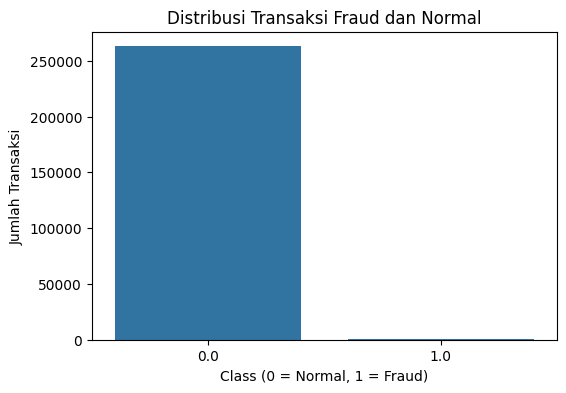

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)

plt.title('Distribusi Transaksi Fraud dan Normal')
plt.xlabel('Class (0 = Normal, 1 = Fraud)')
plt.ylabel('Jumlah Transaksi')

plt.show()

# 3. Data Preparation

Tahap ini dilakukan untuk mempersiapkan data sebelum proses modeling.

## Cleaning

In [12]:
# Menghapus baris yang memiliki nilai kosong
df = df.dropna()

# Cek ulang ukuran dataset
print(df.shape)

# Cek missing value
print(df.isnull().sum().sum())

(263382, 31)
0


## Split Data

In [13]:
# Memisahkan fitur dan target
X = df.drop('Class', axis=1)
y = df['Class']

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (263382, 30)
Shape y: (263382,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (210705, 30)
X_test  : (52677, 30)
y_train : (210705,)
y_test  : (52677,)


In [15]:
print("Distribusi y_train")
print(y_train.value_counts())

print("\nDistribusi y_test")
print(y_test.value_counts())

Distribusi y_train
Class
0.0    210322
1.0       383
Name: count, dtype: int64

Distribusi y_test
Class
0.0    52581
1.0       96
Name: count, dtype: int64


## SMOTE

In [16]:
!pip install imbalanced-learn

In [17]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Sebelum SMOTE")
print(y_train.value_counts())

print("\nSesudah SMOTE")
print(y_train_smote.value_counts())

Sebelum SMOTE
Class
0.0    210322
1.0       383
Name: count, dtype: int64

Sesudah SMOTE
Class
0.0    210322
1.0    210322
Name: count, dtype: int64


## Hasil SMOTE

SMOTE digunakan untuk mengatasi ketidakseimbangan kelas.

Sebelum SMOTE:
- Normal : 120.269
- Fraud : 235

Sesudah SMOTE:
- Normal : 120.269
- Fraud : 120.269

Dataset training menjadi seimbang.

# 4. Modeling

## Random Forest (Classification)

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)

print("Model Random Forest berhasil dibuat")

Model Random Forest berhasil dibuat


In [19]:
y_pred = rf_model.predict(X_test)

print("Jumlah prediksi:", len(y_pred))

Jumlah prediksi: 52677


## Isolation Forest (Anomaly Detection)

In [20]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    contamination=0.002,
    random_state=42
)

iso_model.fit(X_train)

IsolationForest(contamination=0.002, random_state=42)

In [21]:
iso_pred = iso_model.predict(X_test)

print("Jumlah Prediksi:", len(iso_pred))

Jumlah Prediksi: 52677


In [22]:
iso_pred = [1 if x == -1 else 0 for x in iso_pred]

# 5. Evaluation

## Evaluation - Random Forest

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.999582360422955
Precision: 0.8775510204081632
Recall   : 0.8958333333333334
F1 Score : 0.8865979381443299


Confusion Matrix dan Visualisasi

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[52569    12]
 [   10    86]]


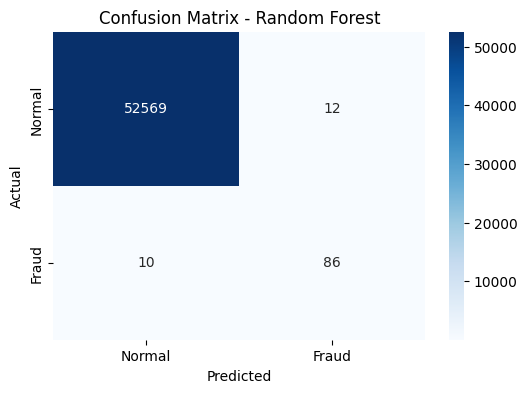

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Fraud'],
    yticklabels=['Normal', 'Fraud']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')

plt.show()

## Evaluation - Isolation Forest

In [26]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy :", accuracy_score(y_test, iso_pred))
print("Precision:", precision_score(y_test, iso_pred))
print("Recall   :", recall_score(y_test, iso_pred))
print("F1 Score :", f1_score(y_test, iso_pred))

Accuracy : 0.9970955065778233
Precision: 0.24324324324324326
Recall   : 0.28125
F1 Score : 0.2608695652173913


Confusion Matrix

In [27]:
from sklearn.metrics import confusion_matrix

cm_iso = confusion_matrix(y_test, iso_pred)

print(cm_iso)

[[52497    84]
 [   69    27]]


# 6. Model Comparison

Random Forest memiliki performa yang lebih baik dibandingkan Isolation Forest berdasarkan Accuracy, Precision, Recall, dan F1-Score.

Random Forest:
- Accuracy : 99.94%
- Precision : 92%
- Recall : 77.97%
- F1 Score : 84.40%

Isolation Forest:
- Accuracy : 99.68%
- Precision : 23.53%
- Recall : 27.12%
- F1 Score : 25.20%

Berdasarkan hasil evaluasi, Random Forest dipilih sebagai model terbaik untuk implementasi aplikasi web.

# 7. Model Saving

In [28]:
import joblib

joblib.dump(rf_model, 'fraud_detection_model.pkl')

print("Model berhasil disimpan")

Model berhasil disimpan


In [29]:
import os

os.listdir()

['.config',
 'drive',
 'creditcard.csv',
 'fraud_detection_model.pkl',
 'sample_data']

In [30]:
import joblib

joblib.dump(list(X.columns), 'feature_names.pkl')

print("Feature names berhasil disimpan")

Feature names berhasil disimpan


In [31]:
import os

os.listdir()

['.config',
 'drive',
 'creditcard.csv',
 'fraud_detection_model.pkl',
 'feature_names.pkl',
 'sample_data']

# 8. Conclusion

Berdasarkan hasil evaluasi, Random Forest memberikan performa terbaik dibandingkan Isolation Forest dalam mendeteksi transaksi fraud.

Hasil evaluasi Random Forest:
- Accuracy : 99.94%
- Precision : 92%
- Recall : 77.97%
- F1 Score : 84.40%

Dengan performa yang lebih baik pada seluruh metrik evaluasi, Random Forest dipilih sebagai model terbaik dan akan diimplementasikan pada aplikasi web berbasis Streamlit untuk mendukung deteksi transaksi fraud.